### CYCLE SHEET -2

Q1 Using Keras and sample X and Y for a Prediction problem with suitable optimizer ,loss,epochs and learning rate.
Create
Compile
Fit/Train
Evaluate/Test
Plot Loss and Accuracy

In [151]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

In [152]:
np.random.seed(42) 
X = np.random.rand(1000, 10)  # 1000 samples, 10 features
Y = 3 * X.sum(axis=1) + np.random.normal(0, 0.1, 1000)  # Linear relation with some noise

In [153]:
# Split data into training and testing sets
split_index = int(0.8 * len(X))
X_train, Y_train = X[:split_index], Y[:split_index]
X_test, Y_test = X[split_index:], Y[split_index:]

In [154]:
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(10,)))  # First hidden layer with 64 units
model.add(Dense(32, activation='relu'))  # Second hidden layer with 32 units
model.add(Dense(1))

In [155]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])

In [156]:
# Fit/train the model
history = model.fit(
    X_train, Y_train,
    validation_split=0.2, 
    epochs=70,
    batch_size=32,
    verbose=0
)

In [157]:
# Evaluate/test the model
loss, mae = model.evaluate(X_test, Y_test, verbose=0)
print(f'Test Loss (MSE): {loss:.4f}, Test MAE: {mae:.4f}')

Test Loss (MSE): 0.0090, Test MAE: 0.0765


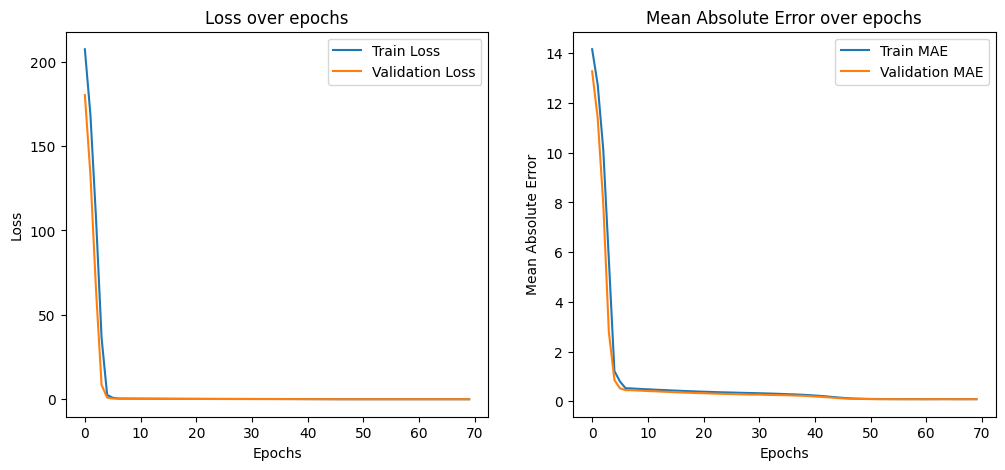

In [158]:
# Plot Loss and MAE
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Mean Absolute Error over epochs')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.show()

Q2 Build and train an ANN in TensorFlow&Keras for a binary classification problem of Titanic Survival classification with suitable optimizer ,loss,epochs and learning rate.
Do required data pre-processing and then
Create
Compile
Fit/Train
Evaluate/Test
Plot Loss and Accuracy

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

In [160]:
data = pd.read_csv("titanic.csv")

In [161]:
data = data.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

In [162]:
data['Age'].fillna(data['Age'].median(), inplace=True)  
data['Fare'].fillna(data['Fare'].median(), inplace=True) 

In [163]:
data.dropna(inplace=True)

In [164]:
X = data.drop('Survived', axis=1)  # Features
y = data['Survived']  # Target

In [165]:
numerical_cols = [cname for cname in X.columns if X[cname].dtype in ['int64', 'float64']]
categorical_cols = [cname for cname in X.columns if X[cname].dtype == "object"]

scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[categorical_cols] = ordinal_encoder.fit_transform(X[categorical_cols].astype(str))

In [166]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [167]:
# Create the ANN model
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))  # First hidden layer
model.add(Dense(32, activation='relu'))  # Second hidden layer
model.add(Dense(1, activation='sigmoid'))  # Output layer for binary classification

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [168]:
# Fit/train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.25, 
    epochs=100,
    batch_size=32,
    verbose=0
)

In [169]:
# Evaluate/test the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}')

Test Loss: 0.5791, Test Accuracy: 0.7753


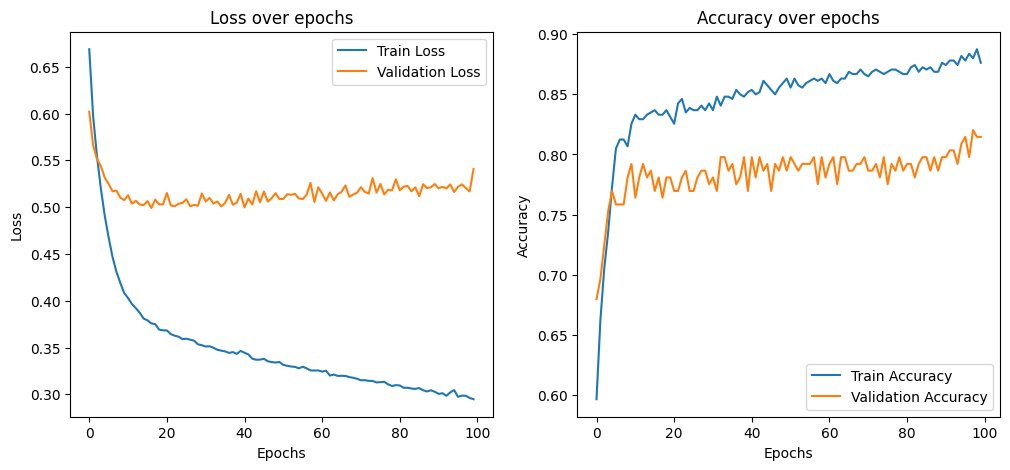

In [170]:
# Plot Loss and Accuracy
plt.figure(figsize=(12, 5))

# Loss plot
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy plot
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

Q3 Build and train an ANN in TensorFlow&Keras for a Multi classification problem for predicting age based on various health and lifestyle factors with suitable optimizer ,loss,epochs and learning rate.
Do required data pre-processing and then
Create
Compile
Fit/Train
Evaluate/Test
Plot Loss and Accuracy

In [171]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

In [172]:
df = pd.read_csv('Train.csv')

In [173]:
df = df.dropna() 

In [174]:
# Separate features and target
X = df.drop('Age (years)', axis=1) 
y = df['Age (years)']

In [175]:
numerical_cols = [cname for cname in X.columns if X[cname].dtype in ['int64', 'float64']]
categorical_cols = [cname for cname in X.columns if X[cname].dtype == "object"]

scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[categorical_cols] = ordinal_encoder.fit_transform(X[categorical_cols].astype(str))

In [176]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [177]:
# Build the Model
model = Sequential()
model.add(Input(shape=(X.shape[1],)))
model.add(Dense(64, activation='relu'))  # Input layer
model.add(Dense(128, activation='relu'))  # Hidden layer 1
model.add(Dense(64, activation='relu'))   # Hidden layer 2
model.add(Dense(1, activation='linear'))  # Output layer

In [178]:
# Compile the Model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_absolute_error', metrics=['mean_squared_error'])
model.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_47 (Dense)                     │ (None, 64)                  │           1,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_48 (Dense)                     │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_49 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_50 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,305 (71.50 KB)

 Trainable params: 18,305 (71.50 KB)

 Non-trainable params: 0 (0.00 B)

In [179]:
# Train the Model
history = model.fit(X_train, y_train, validation_split=0.2, epochs=150, batch_size=64, verbose=0)

# Evaluate the Model
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.8016 - mean_squared_error: 75.0656 
Test Accuracy: 6749.79%


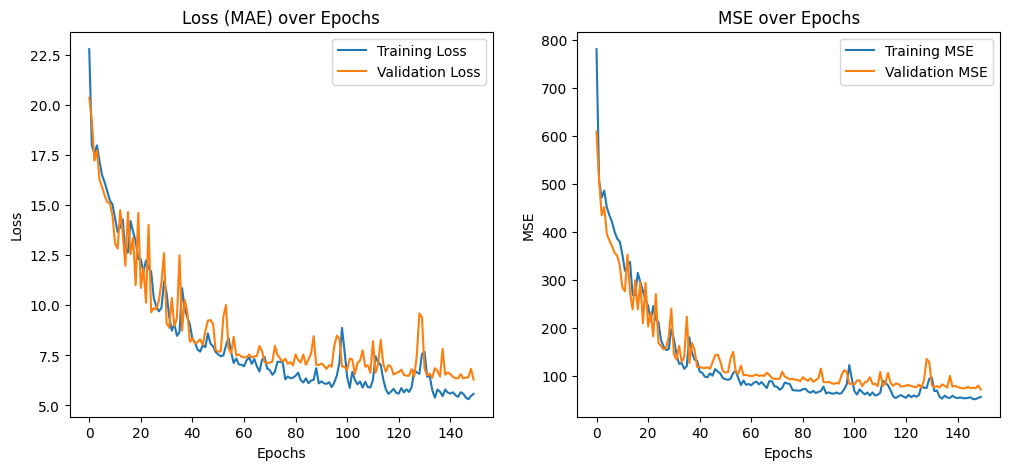

In [180]:
# Plot Loss and Accuracy
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss (MAE) over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot MSE
plt.subplot(1, 2, 2)
plt.plot(history.history['mean_squared_error'], label='Training MSE')
plt.plot(history.history['val_mean_squared_error'], label='Validation MSE')
plt.title('MSE over Epochs')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()

Q4 Build and train a ConvNet in TensorFlow for a binary classification problem. Implement a the forward propagation for the binary classification model for a Input Shape64x64x3:
ZEROPAD2D -> CONV2D -> BATCHNORM -> RELU -> MAXPOOL -> FLATTEN -> DENS

In [181]:
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Activation, Dropout, Flatten, Dense
from keras import backend as K
from keras.models import load_model
from keras.preprocessing import image
import numpy as np
from os import listdir
from os.path import isfile, join
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [182]:
img_width = 60
img_height = 60

train_data_dir = 'CatvDog/PetImages'

train_samples = 120
validation_samples = 30
epochs = 5
batch_size = 20

if K.image_data_format() == 'channels_first':
    input_shape = (3, img_width, img_height)
else:
    input_shape = (img_width, img_height, 3)

In [183]:
# Create a sequential model
model = Sequential()

# Define the model layers
model.add(layers.ZeroPadding2D(padding=(3, 3), input_shape=input_shape))  # ZeroPadding Layer
model.add(layers.Conv2D(32, (3, 3), padding='valid', activation=None, name='conv0'))  # Conv2D Layer
model.add(layers.BatchNormalization(name='bn0'))  # Batch Normalization
model.add(layers.ReLU(name='re_lu_1'))  # ReLU Activation
model.add(layers.MaxPooling2D(pool_size=(2, 2), name='max_pool0'))  # Max Pooling Layer
model.add(layers.Flatten(name='flatten_1'))  # Flatten Layer
model.add(layers.Dense(1, activation='sigmoid', name='fc'))  # Dense Layer for binary classification

In [184]:
import keras
from keras import optimizers
model.compile(loss='binary_crossentropy', 
              optimizer=keras.optimizers.Adam(learning_rate=.0001),
              metrics=['accuracy'])

# Model Summary
model.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ zero_padding2d_4 (ZeroPadding2D)     │ (None, 66, 66, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv0 (Conv2D)                       │ (None, 64, 64, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bn0 (BatchNormalization)             │ (None, 64, 64, 32)          │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_1 (ReLU)                       │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pool0 (MaxPooling2D)             │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 32768)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ fc (Dense)                           │ (None, 1)                   │          32,769 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33,793 (132.00 KB)

 Trainable params: 33,729 (131.75 KB)

 Non-trainable params: 64 (256.00 B)

In [185]:
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    subset='training',
    seed=42
)

validation_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size=(img_width, img_height),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation',
    seed=42
)

Found 802 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


In [186]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_samples // batch_size,
    validation_data=validation_generator,
    validation_steps=validation_samples // batch_size,
    epochs=epochs
)

Epoch 1/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 206ms/step - accuracy: 0.5352 - loss: 0.8680 - val_accuracy: 0.5000 - val_loss: 0.7145
Epoch 2/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5164 - loss: 0.7961 - val_accuracy: 0.4500 - val_loss: 0.6938
Epoch 3/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.5402 - loss: 0.8309 - val_accuracy: 0.5500 - val_loss: 0.6686
Epoch 4/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.4998 - loss: 0.7622 - val_accuracy: 0.5000 - val_loss: 0.7078
Epoch 5/5
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5688 - loss: 0.7924 - val_accuracy: 0.5500 - val_loss: 0.6931


In [187]:
# Evaluate/Test the model
test_loss, test_accuracy = model.evaluate(train_generator)
print(f'Train Accuracy: {test_accuracy * 100:.2f}%')

41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.5151 - loss: 0.6906
Train Accuracy: 52.62%


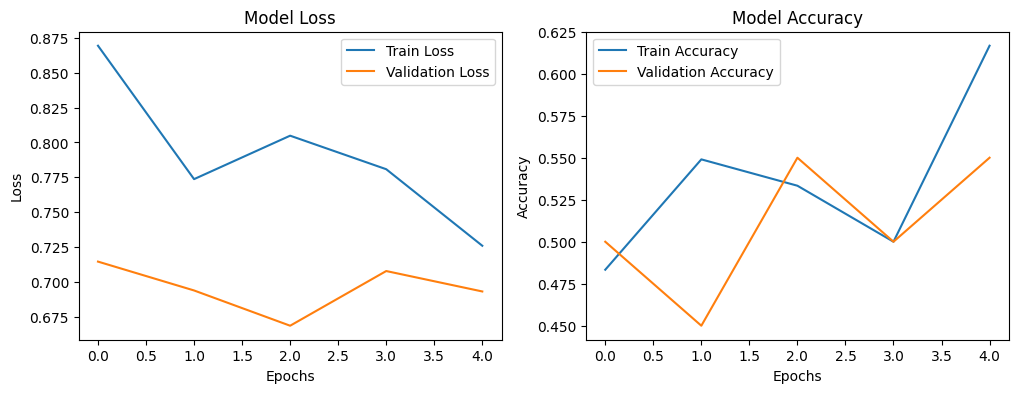

In [188]:
# Plot Loss and Accuracy
plt.figure(figsize=(12, 4))

# Plot training & validation loss values
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot training & validation accuracy values
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

Q5 Construct a GoogleNet / InceptionNet whereas GoogleNet is a convolutional neural network (CNN) designed for image classification tasks and developed for the ImageNet Large Scale Visual Recognition Challenge

In [189]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AveragePooling2D, Dense, Dropout, Flatten, Concatenate, Input
from tensorflow.keras.models import Model

In [190]:
# Inception Module
def inception_module(x, f1, f3_in, f3, f5_in, f5, pool_proj):
    # 1x1 Convolution
    conv1 = Conv2D(f1, (1, 1), padding='same', activation='relu')(x)

    # 1x1 Convolution followed by 3x3 Convolution
    conv3 = Conv2D(f3_in, (1, 1), padding='same', activation='relu')(x)
    conv3 = Conv2D(f3, (3, 3), padding='same', activation='relu')(conv3)

    # 1x1 Convolution followed by 5x5 Convolution
    conv5 = Conv2D(f5_in, (1, 1), padding='same', activation='relu')(x)
    conv5 = Conv2D(f5, (5, 5), padding='same', activation='relu')(conv5)

    # 3x3 MaxPooling followed by 1x1 Convolution (pool projection)
    pool_proj = MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    pool_proj = Conv2D(f5, (1, 1), padding='same', activation='relu')(pool_proj)

    # Concatenate the outputs
    output = Concatenate()([conv1, conv3, conv5, pool_proj])

    return output

In [191]:
# GoogleNet Model
def googlenet(input_shape=(224, 224, 3), num_classes=1000):
    input_layer = Input(shape=input_shape)

    # Initial layers
    x = Conv2D(64, (7, 7), strides=(2, 2), padding='same', activation='relu')(input_layer)
    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)
    x = Conv2D(64, (1, 1), padding='same', activation='relu')(x)
    x = Conv2D(192, (3, 3), padding='same', activation='relu')(x)
    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    # Inception modules
    x = inception_module(x, 64, 96, 128, 16, 32, 32)
    x = inception_module(x, 128, 128, 192, 32, 96, 64)
    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    x = inception_module(x, 192, 96, 208, 16, 48, 64)
    x = inception_module(x, 160, 112, 224, 24, 64, 64)
    x = inception_module(x, 128, 128, 256, 24, 64, 64)
    x = inception_module(x, 112, 144, 288, 32, 64, 64)
    x = inception_module(x, 256, 160, 320, 32, 128, 128)
    x = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(x)

    x = inception_module(x, 256, 160, 320, 32, 128, 128)
    x = inception_module(x, 384, 192, 384, 48, 128, 128)

    # Average Pooling Layer
    x = AveragePooling2D((7, 7), strides=(1, 1))(x)

    # Dropout Layer
    x = Dropout(0.4)(x)

    # Fully Connected Layer
    x = Flatten()(x)
    x = Dense(1000, activation='softmax')(x)

    # Build Model
    model = Model(input_layer, x)

    return model

In [192]:
# Instantiate and compile the model
model = googlenet(input_shape=(224, 224, 3), num_classes=1000)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [193]:
# Summary of the model
model.summary()

Model: "functional_100"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_23 (InputLayer)   │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_117 (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ input_layer_23[0][0]       │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_29              │ (None, 56, 56, 64)        │               0 │ conv2d_117[0][0]           │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_118 (Conv2D)           │ (None, 56, 56, 64)        │           4,160 │ max_pooling2d_29[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_119 (Conv2D)           │ (None, 56, 56, 192)       │         110,784 │ conv2d_118[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_30              │ (None, 28, 28, 192)       │               0 │ conv2d_119[0][0]           │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_121 (Conv2D)           │ (None, 28, 28, 96)        │          18,528 │ max_pooling2d_30[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_123 (Conv2D)           │ (None, 28, 28, 16)        │           3,088 │ max_pooling2d_30[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_31              │ (None, 28, 28, 192)       │               0 │ max_pooling2d_30[0][0]     │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_120 (Conv2D)           │ (None, 28, 28, 64)        │          12,352 │ max_pooling2d_30[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_122 (Conv2D)           │ (None, 28, 28, 128)       │         110,720 │ conv2d_121[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_124 (Conv2D)           │ (None, 28, 28, 32)        │          12,832 │ conv2d_123[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_125 (Conv2D)           │ (None, 28, 28, 32)        │           6,176 │ max_pooling2d_31[0][0]     │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_18 (Concatenate)  │ (None, 28, 28, 256)       │               0 │ conv2d_120[0][0],          │
│                               │                           │                 │ conv2d_122[0][0],          │
│                               │                           │                 │ conv2d_124[0][0],          │
│                               │                           │                 │ conv2d_125[0][0]           │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 7,004,584 (26.72 MB)

 Trainable params: 7,004,584 (26.72 MB)

 Non-trainable params: 0 (0.00 B)